In [10]:
from scipy.io import loadmat
import pandas as pd

x = loadmat('/kaggle/input/golfdata/golfDB.mat')
l = list(x['golfDB'][0])
d = dict()
for idx, k in enumerate(l):
    d["{:3d}".format(idx)] = list(l[idx])
df = pd.DataFrame(d).T
df.columns = ["id","youtube_id","player", "sex", "club","view","slow","events","bbox","split"]

# data format cleansing
df['id'] = df['id'].apply(lambda x: x[0][0])
df['youtube_id'] = df['youtube_id'].apply(lambda x: x[0])
df['player'] = df['player'].apply(lambda x: x[0])
df['sex'] = df['sex'].apply(lambda x: x[0])
df['club'] = df['club'].apply(lambda x: x[0])
df['view'] = df['view'].apply(lambda x: x[0])
df['slow'] = df['slow'].apply(lambda x: x[0][0])
df['events'] = df['events'].apply(lambda x: x[0])
df['bbox'] = df['bbox'].apply(lambda x: x[0])
df['split'] = df['split'].apply(lambda x: x[0][0])

df.index = df.index.astype(int)
df.to_pickle('golfDB.pkl')

for i in range(1, 5):
    val_split = df.loc[df['split'] == i]
    val_split = val_split.reset_index()
    val_split = val_split.drop(columns=['index'])
    val_split.to_pickle("val_split_{:1d}.pkl".format(i))

    train_split = df.loc[df['split'] != i]
    train_split = train_split.reset_index()
    train_split = train_split.drop(columns=['index'])
    train_split.to_pickle("train_split_{:1d}.pkl".format(i))

print("Number of unique YouTube videos: {:3d}".format(len(df['youtube_id'].unique())))
print("Number of annotations: {:3d}".format(len(df.id)))

Number of unique YouTube videos: 580
Number of annotations: 1400


In [11]:
import os
import os.path as osp
import cv2
import pickle
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset


# ================= TRANSFORMS (RGB only) =================
class Resize(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        images, poses, labels = sample['images'], sample['poses'], sample['labels']
        resized = [cv2.resize(img, (self.size, self.size)) for img in images]
        return {
            'images': np.asarray(resized),
            'poses': poses,
            'labels': labels
        }


class ToTensor(object):
    def __call__(self, sample):
        images, poses, labels = sample['images'], sample['poses'], sample['labels']

        images = images.transpose((0, 3, 1, 2))  # HWC -> CHW
        images = torch.from_numpy(images).float().div(255.)

        poses = torch.from_numpy(poses).float()   # (T, 13, 3)
        labels = torch.from_numpy(labels).long()

        return {
            'images': images,
            'poses': poses,
            'labels': labels
        }


class Normalize(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

    def __call__(self, sample):
        images, poses, labels = sample['images'], sample['poses'], sample['labels']
        images.sub_(self.mean[None, :, None, None]).div_(self.std[None, :, None, None])
        return {
            'images': images,
            'poses': poses,
            'labels': labels
        }


# ================= DATASET =================
class GolfDBRGBPose(Dataset):
    def __init__(
        self,
        data_file,
        vid_dir,
        pose_pkl,
        seq_length,
        transform=None,
        train=True
    ):
        self.df = pd.read_pickle(data_file)
        self.vid_dir = vid_dir
        self.seq_length = seq_length
        self.transform = transform
        self.train = train

        with open(pose_pkl, "rb") as f:
            self.pose_dict = pickle.load(f)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        a = self.df.loc[idx, :]
        video_id = a['id']

        events = a['events'].copy()
        events -= events[0]

        pose_all = self.pose_dict[video_id]  # (T_video, 13, 3)

        images, poses, labels = [], [], []

        cap = cv2.VideoCapture(
            osp.join(self.vid_dir, f"{video_id}.mp4")
        )

        # ================= TRAIN MODE =================
        if self.train:
            start_frame = np.random.randint(events[-1] + 1)
            cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
            pos = start_frame

            while len(images) < self.seq_length:
                ret, img = cap.read()
                if not ret:
                    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
                    pos = 0
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)

                if pos < len(pose_all):
                    poses.append(pose_all[pos])
                else:
                    poses.append(np.zeros((13, 3)))

                if pos in events[1:-1]:
                    labels.append(np.where(events[1:-1] == pos)[0][0])
                else:
                    labels.append(8)

                pos += 1

            cap.release()

        # ================= TEST / VAL MODE =================
        else:
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            for pos in range(total_frames):
                ret, img = cap.read()
                if not ret:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                images.append(img)

                if pos < len(pose_all):
                    poses.append(pose_all[pos])
                else:
                    poses.append(np.zeros((13, 3)))

                if pos in events[1:-1]:
                    labels.append(np.where(events[1:-1] == pos)[0][0])
                else:
                    labels.append(8)

            cap.release()

        sample = {
            'images': np.asarray(images),  # (T, H, W, 3)
            'poses':  np.asarray(poses),   # (T, 13, 3)
            'labels': np.asarray(labels)
        }

        if self.transform:
            sample = self.transform(sample)

        return sample
class NormalizePose(object):
    """
    Normalize pose:
    - Root-centered (mid-hip)
    - Scale by torso length
    - Keep confidence unchanged
    """
    def __init__(self, eps=1e-6):
        self.eps = eps

        self.LEFT_HIP = 7
        self.RIGHT_HIP = 8
        self.LEFT_SHOULDER = 1
        self.RIGHT_SHOULDER = 2

    def __call__(self, sample):
        images, poses, labels = sample['images'], sample['poses'], sample['labels']

        poses = poses.copy()  # (T, 13, 3)

        # -------- root (mid-hip) --------
        hip_center = (
            poses[:, self.LEFT_HIP, :2] +
            poses[:, self.RIGHT_HIP, :2]
        ) / 2.0  # (T, 2)

        poses[:, :, :2] -= hip_center[:, None, :]

        # -------- scale (torso length) --------
        shoulder_center = (
            poses[:, self.LEFT_SHOULDER, :2] +
            poses[:, self.RIGHT_SHOULDER, :2]
        ) / 2.0

        torso = np.linalg.norm(
            shoulder_center, axis=1, keepdims=True
        )  # (T,1)

        torso = np.maximum(torso, self.eps)

        poses[:, :, :2] /= torso[:, None, :]

        return {
            'images': images,
            'poses': poses,
            'labels': labels
        }


In [12]:
'''
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2

class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        max = self.mlp(self.max_pool(x))
        return x * self.sigmoid(avg + max)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.cat([avg, max], dim=1)
        return x * self.sigmoid(self.conv(attn))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

class EventDetector(nn.Module):
    def __init__(
        self,
        pretrain=True,
        width_mult=1.0,

        # RGB branch
        rgb_gru_hidden=256,
        rgb_lstm_hidden=256,
        rgb_lstm_layers=1,

        # Pose branch
        pose_dim=26,
        pose_gru_hidden=128,
        pose_lstm_hidden=128,
        pose_lstm_layers=1,

        bidirectional=True,
        dropout=True
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.rgb_lstm_layers = rgb_lstm_layers
        self.pose_lstm_layers = pose_lstm_layers

        # ============ RGB BRANCH ============
        net = mobilenet_v2(pretrained=pretrain, width_mult=width_mult)
        self.cnn = net.features
        cnn_out_dim = net.last_channel   # 1280

        self.cbam = CBAM(cnn_out_dim)
        self.rgb_drop = nn.Dropout(0.3) if dropout else nn.Identity()

        self.rgb_gru = nn.GRU(
            input_size=cnn_out_dim,
            hidden_size=rgb_gru_hidden,
            batch_first=True
        )

        self.rgb_lstm = nn.LSTM(
            input_size=rgb_gru_hidden,
            hidden_size=rgb_lstm_hidden,
            num_layers=rgb_lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if rgb_lstm_layers > 1 else 0.0
        )

        rgb_out_dim = 2 * rgb_lstm_hidden if bidirectional else rgb_lstm_hidden

        # ============ POSE BRANCH ============
        self.pose_gru = nn.GRU(
            input_size=pose_dim,
            hidden_size=pose_gru_hidden,
            batch_first=True
        )

        self.pose_lstm = nn.LSTM(
            input_size=pose_gru_hidden,
            hidden_size=pose_lstm_hidden,
            num_layers=pose_lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if pose_lstm_layers > 1 else 0.0
        )

        pose_out_dim = 2 * pose_lstm_hidden if bidirectional else pose_lstm_hidden

        # ============ FUSION ============
        self.classifier = nn.Linear(
            rgb_out_dim + pose_out_dim,
            9
        )


    def _init_lstm_hidden(self, layers, hidden, batch, device):
        num_dir = 2 if self.bidirectional else 1
        h0 = torch.zeros(num_dir * layers, batch, hidden, device=device)
        c0 = torch.zeros_like(h0)
        return h0, c0


    def forward(self, images, poses):
        """
        images: (B, T, 3, H, W)
        poses:  (B, T, 26)
        """
        B, T, C, H, W = images.size()
        device = images.device

        # ===== RGB =====
        x = images.view(B * T, C, H, W)
        x = self.cnn(x)               # (B*T, 1280, H', W')
        x = self.cbam(x)              # attention trước GAP
        x = x.mean(dim=[2, 3])        # GAP → (B*T, 1280)
        x = self.rgb_drop(x)

        x = x.view(B, T, -1)
        x, _ = self.rgb_gru(x)

        h0, c0 = self._init_lstm_hidden(
            self.rgb_lstm_layers,
            self.rgb_lstm.hidden_size,
            B,
            device
        )
        x, _ = self.rgb_lstm(x, (h0, c0))   # (B, T, Drgb)

        # ===== POSE =====
        # ===== POSE =====
        B, T, J, C = poses.shape          # (B, T, 13, 3)
        
        poses = poses[:, :, :, :2]        # bỏ confidence → (B, T, 13, 2)
        poses = poses.reshape(B, T, 26)   # flatten → (B, T, 26)
        
        p, _ = self.pose_gru(poses)
        
        h0p, c0p = self._init_lstm_hidden(
            self.pose_lstm_layers,
            self.pose_lstm.hidden_size,
            B,
            device
        )
        p, _ = self.pose_lstm(p, (h0p, c0p))


        # ===== FUSION =====
        feat = torch.cat([x, p], dim=-1)     # (B, T, Dtotal)
        out = self.classifier(feat)

        return out.view(B * T, -1)
'''


'\nimport torch\nimport torch.nn as nn\nfrom torchvision.models import mobilenet_v2\n\nclass ChannelAttention(nn.Module):\n    def __init__(self, channels, reduction=16):\n        super().__init__()\n        self.avg_pool = nn.AdaptiveAvgPool2d(1)\n        self.max_pool = nn.AdaptiveMaxPool2d(1)\n\n        self.mlp = nn.Sequential(\n            nn.Conv2d(channels, channels // reduction, 1, bias=False),\n            nn.ReLU(inplace=True),\n            nn.Conv2d(channels // reduction, channels, 1, bias=False)\n        )\n\n        self.sigmoid = nn.Sigmoid()\n\n    def forward(self, x):\n        avg = self.mlp(self.avg_pool(x))\n        max = self.mlp(self.max_pool(x))\n        return x * self.sigmoid(avg + max)\n\n\nclass SpatialAttention(nn.Module):\n    def __init__(self, kernel_size=7):\n        super().__init__()\n        padding = kernel_size // 2\n        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)\n        self.sigmoid = nn.Sigmoid()\n\n    def forward(s

In [13]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2


# ================= CBAM =================
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.mlp(self.avg_pool(x))
        max = self.mlp(self.max_pool(x))
        return x * self.sigmoid(avg + max)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max, _ = torch.max(x, dim=1, keepdim=True)
        attn = torch.cat([avg, max], dim=1)
        return x * self.sigmoid(self.conv(attn))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x


# ================= EVENT DETECTOR =================
class EventDetector(nn.Module):
    def __init__(
        self,
        pretrain=True,
        width_mult=1.0,

        # RGB branch
        rgb_lstm_hidden=256,
        rgb_lstm_layers=1,
        rgb_gru_hidden=256,

        # Pose branch
        pose_dim=26,
        pose_lstm_hidden=128,
        pose_lstm_layers=1,
        pose_gru_hidden=128,

        bidirectional=True,
        dropout=True,
        num_classes=9
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.rgb_lstm_layers = rgb_lstm_layers
        self.pose_lstm_layers = pose_lstm_layers

        # ============ RGB BRANCH ============
        net = mobilenet_v2(pretrained=pretrain, width_mult=width_mult)
        self.cnn = net.features
        cnn_out_dim = net.last_channel  # 1280

        self.cbam = CBAM(cnn_out_dim)
        self.rgb_drop = nn.Dropout(0.3) if dropout else nn.Identity()

        self.rgb_lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=rgb_lstm_hidden,
            num_layers=rgb_lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if rgb_lstm_layers > 1 else 0.0
        )

        rgb_lstm_out = 2 * rgb_lstm_hidden if bidirectional else rgb_lstm_hidden

        self.rgb_gru = nn.GRU(
            input_size=rgb_lstm_out,
            hidden_size=rgb_gru_hidden,
            batch_first=True
        )

        rgb_out_dim = rgb_gru_hidden

        # ============ POSE BRANCH ============
        self.pose_lstm = nn.LSTM(
            input_size=pose_dim,
            hidden_size=pose_lstm_hidden,
            num_layers=pose_lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if pose_lstm_layers > 1 else 0.0
        )

        pose_lstm_out = 2 * pose_lstm_hidden if bidirectional else pose_lstm_hidden

        self.pose_gru = nn.GRU(
            input_size=pose_lstm_out,
            hidden_size=pose_gru_hidden,
            batch_first=True
        )

        pose_out_dim = pose_gru_hidden

        # ============ CROSS-ATTENTION ============
        self.pose_proj = nn.Linear(pose_out_dim, rgb_out_dim)

        # ============ FUSION ============
        self.classifier = nn.Linear(
            rgb_out_dim + pose_out_dim,
            num_classes
        )

    def _init_lstm_hidden(self, layers, hidden, batch, device):
        num_dir = 2 if self.bidirectional else 1
        h0 = torch.zeros(num_dir * layers, batch, hidden, device=device)
        c0 = torch.zeros_like(h0)
        return h0, c0

    def forward(self, images, poses):
        """
        images: (B, T, 3, H, W)
        poses : (B, T, J, C)
        """
        B, T, C, H, W = images.size()
        device = images.device

        # ===== RGB =====
        x = images.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.cbam(x)
        x = x.mean(dim=[2, 3])          # GAP
        x = self.rgb_drop(x)
        x = x.view(B, T, -1)

        h0, c0 = self._init_lstm_hidden(
            self.rgb_lstm_layers,
            self.rgb_lstm.hidden_size,
            B,
            device
        )
        x, _ = self.rgb_lstm(x, (h0, c0))   # LSTM first
        x, _ = self.rgb_gru(x)              # GRU after

        # ===== POSE =====
        poses = poses[:, :, :, :2].reshape(B, T, 26)

        h0p, c0p = self._init_lstm_hidden(
            self.pose_lstm_layers,
            self.pose_lstm.hidden_size,
            B,
            device
        )
        p, _ = self.pose_lstm(poses, (h0p, c0p))  # LSTM first
        p, _ = self.pose_gru(p)                   # GRU after

        # ===== CROSS-ATTENTION (RGB ← Pose) =====
        p_proj = self.pose_proj(p)  # (B,T,Drgb)
        D = x.size(-1)

        attn = torch.softmax(
            torch.bmm(x, p_proj.transpose(1, 2)) / (D ** 0.5),
            dim=-1
        )
        x = x + torch.bmm(attn, p_proj)   # residual

        # ===== FUSION =====
        feat = torch.cat([x, p], dim=-1)
        out = self.classifier(feat)

        return out.view(B * T, -1)

In [14]:
import numpy as np
import os

class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def correct_preds(probs, labels, tol=-1):
    """
    Gets correct events in full-length sequence using tolerance based on number of frames from address to impact.
    Used during validation only.
    :param probs: (sequence_length, 9)
    :param labels: (sequence_length,)
    :return: array indicating correct events in predicted sequence (8,)
    """

    events = np.where(labels < 8)[0]
    preds = np.zeros(len(events))
    if tol == -1:
        tol = int(max(np.round((events[5] - events[0])/30), 1))
    for i in range(len(events)):
        preds[i] = np.argsort(probs[:, i])[-1]
    deltas = np.abs(events-preds)
    correct = (deltas <= tol).astype(np.uint8)
    return events, preds, deltas, tol, correct


def freeze_layers(num_freeze, model):
    """
    Freeze first `num_freeze` blocks of MobileNetV2 features
    """
    cnt = 0
    for block in model.cnn.children():
        if cnt < num_freeze:
            for p in block.parameters():
                p.requires_grad = False
        cnt += 1


In [15]:
'''
import os
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

# ---- Training configuration ----
split = 1
iterations = 4000
it_save = 100
n_cpu =6
seq_length = 32
bs = 22
device = "cuda"

# ---- Initialize model ----
model = EventDetector(
    pretrain=True,
    rgb_lstm_layers=1,
    rgb_lstm_hidden=256,
    pose_lstm_layers=1,
    pose_lstm_hidden=128,
    bidirectional=True,
    dropout=False
).to(device)

model.train()
print(model)

# ---- (OPTIONAL) Freeze backbone ----
# freeze first 10 MobileNetV2 blocks
freeze_layers(num_freeze=10, model=model)

# ---- Dataset & DataLoader ----
dataset = GolfDBRGBPose(
    data_file=f'/kaggle/working/train_split_{split}.pkl',
    vid_dir='/kaggle/input/golfdata/videos_160/videos_160',
    pose_pkl='/kaggle/input/golfdata/golfdb_pose.pkl',
    seq_length=seq_length,
    transform=transforms.Compose([
        Resize(224),
        NormalizePose(),
        ToTensor(),   # ❗ bỏ img_size
        Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225])
    ]),
    train=True
)


data_loader = DataLoader(
    dataset,
    batch_size=bs,
    shuffle=True,
    num_workers=n_cpu,
    drop_last=True
)

# ---- Loss & optimizer ----
weights = torch.FloatTensor([1/8]*8 + [1/35]).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

# ---- Make sure folder exists ----
os.makedirs("models", exist_ok=True)

# ---- Training loop ----
i = 0
losses = AverageMeter()

while i < iterations:
    for sample in data_loader:

        # ---- Move to GPU ----
        images = sample['images'].to(device)   # (B, T, 3, H, W)
        poses  = sample['poses'].to(device)    # (B, T, 26)
        labels = sample['labels'].to(device)   # (B, T)

        # ---- Forward ----
        logits = model(images, poses)           # (B*T, 9)
        labels = labels.view(bs * seq_length)   # (B*T)

        # ---- Loss ----
        loss = criterion(logits, labels)

        # ---- Backprop ----
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # ---- Logging ----
        losses.update(loss.item(), bs * seq_length)
        print(f"Iter {i:5d} | Loss {losses.val:.4f} (avg {losses.avg:.4f})")

        # ---- Save checkpoint ----
        if i > 1700 and (i + 1) % it_save == 0:
            torch.save({
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "iter": i + 1
            }, f"models/swingnet_iter_{i+1}.pth.tar")
            print(f"✔ Saved model at iter {i+1}")

        i += 1
        if i >= iterations:
            break
'''

'\nimport os\nimport torch\nfrom torch.utils.data import DataLoader\nfrom torchvision import transforms\n\n# ---- Training configuration ----\nsplit = 1\niterations = 4000\nit_save = 100\nn_cpu =6\nseq_length = 32\nbs = 22\ndevice = "cuda"\n\n# ---- Initialize model ----\nmodel = EventDetector(\n    pretrain=True,\n    rgb_lstm_layers=1,\n    rgb_lstm_hidden=256,\n    pose_lstm_layers=1,\n    pose_lstm_hidden=128,\n    bidirectional=True,\n    dropout=False\n).to(device)\n\nmodel.train()\nprint(model)\n\n# ---- (OPTIONAL) Freeze backbone ----\n# freeze first 10 MobileNetV2 blocks\nfreeze_layers(num_freeze=10, model=model)\n\n# ---- Dataset & DataLoader ----\ndataset = GolfDBRGBPose(\n    data_file=f\'/kaggle/working/train_split_{split}.pkl\',\n    vid_dir=\'/kaggle/input/golfdata/videos_160/videos_160\',\n    pose_pkl=\'/kaggle/input/golfdata/golfdb_pose.pkl\',\n    seq_length=seq_length,\n    transform=transforms.Compose([\n        Resize(224),\n        NormalizePose(),\n        ToTen

In [16]:
'''
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
import torch.nn.functional as F
import numpy as np


@torch.no_grad()
def eval_pose(model, split, seq_length, n_cpu, disp=False):

    dataset = GolfDBRGBPose(
        data_file=f'/kaggle/working/val_split_{split}.pkl',
        vid_dir='/kaggle/input/golfdata/videos_160/videos_160',
        pose_pkl='/kaggle/input/golfdata/golfdb_pose.pkl',
        seq_length=seq_length,
        transform=transforms.Compose([
            Resize(224),
            NormalizePose(),   # ✅ PHẢI có nếu train có
            ToTensor(),
            Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ]),
        train=False
    )
    data_loader = DataLoader(
        dataset,
        batch_size=1,
        shuffle=False,
        num_workers=n_cpu,
        drop_last=False
    )

    correct = []

    for i, sample in enumerate(data_loader):
        print(f"Iter {i:5d}")
        images = sample['images'].cuda()   # (1, T, 3, H, W)
        poses  = sample['poses'].cuda()    # (1, T, 26)
        labels = sample['labels'].view(-1).cpu().numpy()  # (T,)

        T = images.shape[1]
        probs = []

        batch = 0
        while batch * seq_length < T:
            start = batch * seq_length
            end = min((batch + 1) * seq_length, T)

            image_batch = images[:, start:end]
            pose_batch  = poses[:, start:end]

            logits = model(image_batch, pose_batch)   # (t, 9)
            prob = F.softmax(logits, dim=1).cpu().numpy()
            probs.append(prob)

            batch += 1

        probs = np.concatenate(probs, axis=0)  # (T, 9)

        _, _, _, _, c = correct_preds(probs, labels)
        correct.append(c)

    correct = np.array(correct)          # (num_videos, 8)
    avg_per_event = np.mean(correct, 0)
    PCE = np.mean(avg_per_event)

    if disp:
        event_names = ['A', 'TU', 'MB', 'T', 'MD', 'I', 'MFT', 'F']
        print("Average per event:")
        for name, val in zip(event_names, avg_per_event):
            print(f"{name}: {val*100:.1f}%")
        print(f"Overall PCE: {PCE*100:.1f}%")

    return PCE, avg_per_event
if __name__ == '__main__':
    split = 1
    seq_length = 64
    n_cpu = 6

    model = EventDetector(
        pretrain=False,          # ❗ khi load checkpoint thì để False
        rgb_lstm_layers=1,
        rgb_lstm_hidden=256,
        pose_lstm_layers=1,
        pose_lstm_hidden=128,
        bidirectional=True,
        dropout=False
    ).cuda()

    ckpt = torch.load('/kaggle/working/models/swingnet_iter_1800.pth.tar')
    model.load_state_dict(ckpt['model_state_dict'], strict=True)
    model.eval()

    PCE, avg_per_event = eval_pose(
        model,
        split,
        seq_length,
        n_cpu,
        disp=True
    )
'''

'\nimport torch\nfrom torch.utils.data import DataLoader\nfrom torchvision import transforms\nimport torch.nn.functional as F\nimport numpy as np\n\n\n@torch.no_grad()\ndef eval_pose(model, split, seq_length, n_cpu, disp=False):\n\n    dataset = GolfDBRGBPose(\n        data_file=f\'/kaggle/working/val_split_{split}.pkl\',\n        vid_dir=\'/kaggle/input/golfdata/videos_160/videos_160\',\n        pose_pkl=\'/kaggle/input/golfdata/golfdb_pose.pkl\',\n        seq_length=seq_length,\n        transform=transforms.Compose([\n            Resize(224),\n            NormalizePose(),   # ✅ PHẢI có nếu train có\n            ToTensor(),\n            Normalize(\n                mean=[0.485, 0.456, 0.406],\n                std=[0.229, 0.224, 0.225]\n            )\n        ]),\n        train=False\n    )\n    data_loader = DataLoader(\n        dataset,\n        batch_size=1,\n        shuffle=False,\n        num_workers=n_cpu,\n        drop_last=False\n    )\n\n    correct = []\n\n    for i, sample in

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loading checkpoint from: /kaggle/input/golfdata/swingnet_iter_1800.pth.tar
Processing Video ID: 30 | Frames: 373


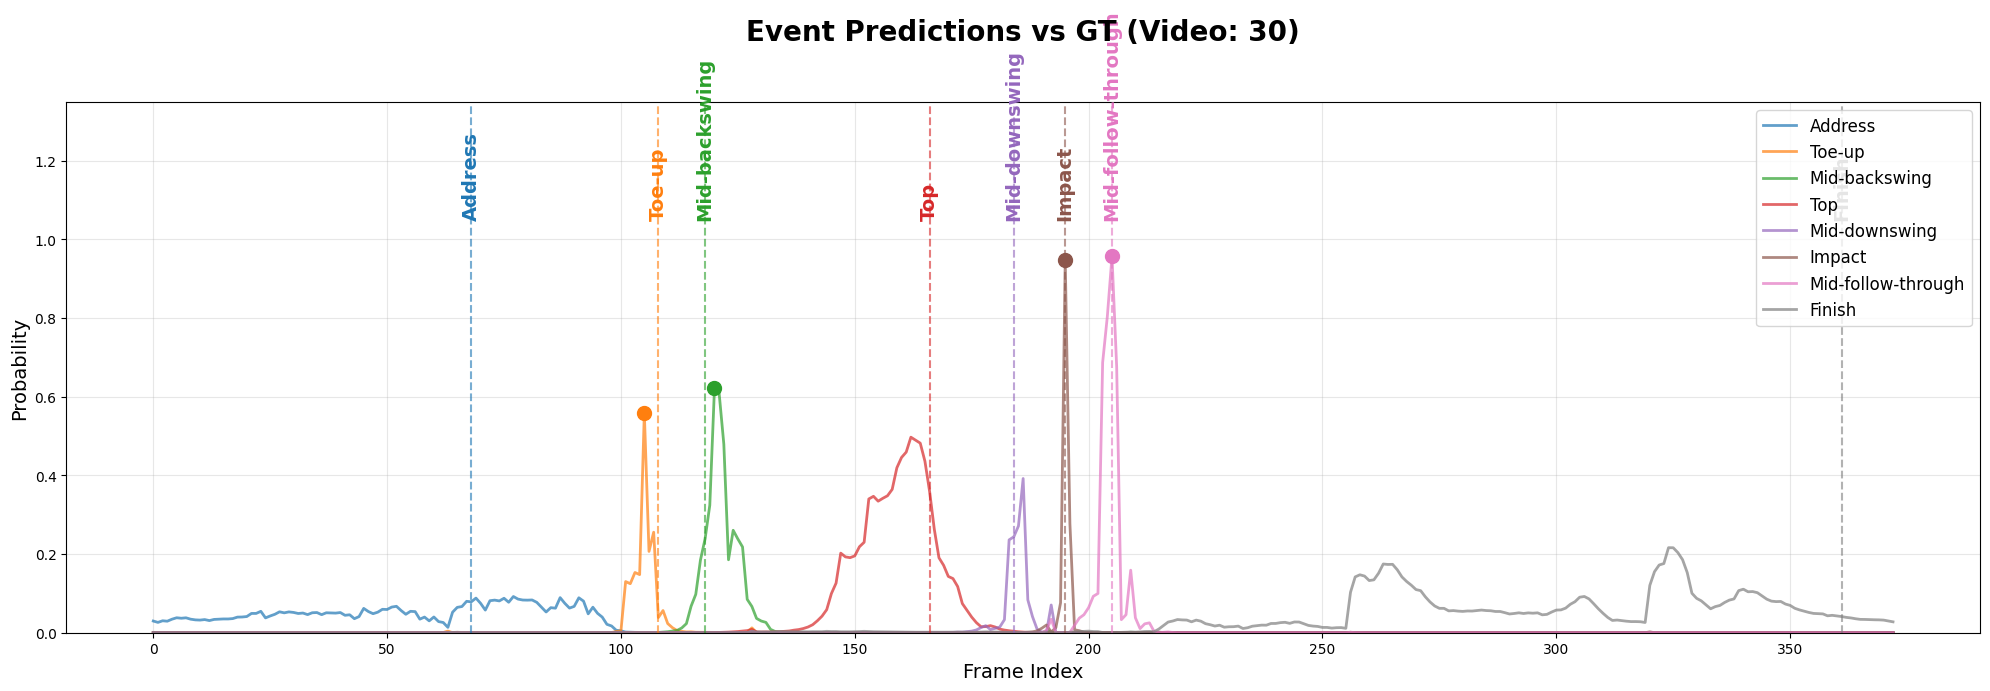

Creating annotated video: demo_golf_predict_v2.mp4 ...
✔ Done! Video saved to: demo_golf_predict_v2.mp4


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import os.path as osp
from torchvision import transforms  # <--- Đã thêm dòng này để sửa lỗi NameError

# ================= 1. HÀM VISUALIZE =================
def visualize_and_save_video(model, split, video_idx=0, seq_length=64, output_name="predicted_video.mp4"):
    """
    Visualize với Tiêu đề cao hơn và Nhãn to, rõ ràng hơn.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Đảm bảo device được định nghĩa

    # Khởi tạo Dataset
    dataset = GolfDBRGBPose(
        data_file=f'/kaggle/working/val_split_{split}.pkl',
        vid_dir='/kaggle/input/golfdata/videos_160/videos_160',
        pose_pkl='/kaggle/input/golfdata/golfdb_pose.pkl',
        seq_length=seq_length,
        transform=transforms.Compose([
            Resize(224),
            NormalizePose(),
            ToTensor(),
            Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ]),
        train=False
    )
    
    # Kiểm tra index hợp lệ
    if video_idx >= len(dataset):
        print(f"Error: video_idx {video_idx} vượt quá số lượng video trong tập val ({len(dataset)})")
        return

    sample = dataset[video_idx]
    images = sample['images'].to(device).unsqueeze(0)
    poses  = sample['poses'].to(device).unsqueeze(0)
    labels = sample['labels'].numpy()
    
    video_id = dataset.df.iloc[video_idx]['id']
    print(f"Processing Video ID: {video_id} | Frames: {images.shape[1]}")

    model.eval()
    T = images.shape[1]
    probs_all = []
    
    with torch.no_grad():
        batch_idx = 0
        while batch_idx * seq_length < T:
            start = batch_idx * seq_length
            end = min((batch_idx + 1) * seq_length, T)
            logits = model(images[:, start:end], poses[:, start:end])
            probs = F.softmax(logits, dim=1).cpu().numpy()
            probs_all.append(probs)
            batch_idx += 1
            
    probs_all = np.concatenate(probs_all, axis=0)

    # --- VẼ BIỂU ĐỒ ---
    event_names = ['Address', 'Toe-up', 'Mid-backswing', 'Top', 'Mid-downswing', 'Impact', 'Mid-follow-through', 'Finish']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    plt.figure(figsize=(20, 7))
    for i in range(8):
        plt.plot(probs_all[:, i], label=event_names[i], color=colors[i], alpha=0.7, linewidth=2)
        if np.max(probs_all[:, i]) > 0.5:
            peak_frame = np.argmax(probs_all[:, i])
            plt.plot(peak_frame, probs_all[peak_frame, i], 'o', color=colors[i], markersize=10)

    gt_frames = np.where(labels < 8)[0]
    for frame in gt_frames:
        event_cls = labels[frame]
        plt.axvline(x=frame, color=colors[event_cls], linestyle='--', alpha=0.6)
        plt.text(frame, 1.05, event_names[event_cls], rotation=90, va='bottom', ha='center',
                 color=colors[event_cls], fontsize=14, fontweight='bold')

    plt.title(f'Event Predictions vs GT (Video: {video_id})', fontsize=20, y=1.1, fontweight='bold')
    plt.xlabel('Frame Index', fontsize=14)
    plt.ylabel('Probability', fontsize=14)
    plt.ylim(0, 1.35)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- TẠO VIDEO ---
    print(f"Creating annotated video: {output_name} ...")
    original_video_path = osp.join(dataset.vid_dir, f"{video_id}.mp4")
    cap = cv2.VideoCapture(original_video_path)
    
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, fps, (width, height))
    
    frame_idx = 0
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    thickness = 2
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        if frame_idx >= len(probs_all): break
        
        probs = probs_all[frame_idx]
        pred_cls = np.argmax(probs)
        pred_conf = probs[pred_cls]
        
        # PRED
        if pred_cls < 8:
            text_pred = f"PRED: {event_names[pred_cls]} ({pred_conf:.2f})"
            color_pred = (0, 255, 0)
        else:
            text_pred = f"PRED: No Event ({pred_conf:.2f})"
            color_pred = (200, 200, 200)
        cv2.putText(frame, text_pred, (20, 40), font, font_scale, color_pred, thickness, cv2.LINE_AA)
        
        # GT
        gt_cls = labels[frame_idx]
        if gt_cls < 8:
            text_gt = f"GT: {event_names[gt_cls]}"
            color_gt = (0, 0, 255)
            cv2.circle(frame, (width-50, 50), 15, (0, 0, 255), -1)
        else:
            text_gt = "GT: No Event"
            color_gt = (200, 200, 200)
        cv2.putText(frame, text_gt, (20, 80), font, font_scale, color_gt, thickness, cv2.LINE_AA)

        out.write(frame)
        frame_idx += 1
        
    cap.release()
    out.release()
    print(f"✔ Done! Video saved to: {output_name}")


# ================= 2. LOAD MODEL & CHẠY (QUAN TRỌNG) =================
# Bạn phải load model object, không phải string path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Khởi tạo kiến trúc model (phải khớp với lúc train)
model = EventDetector(
    pretrain=False,         # Load checkpoint thì tắt pretrain để đỡ tốn time download
    rgb_lstm_layers=1,
    rgb_lstm_hidden=256,
    pose_lstm_layers=1,
    pose_lstm_hidden=128,
    bidirectional=True,
    dropout=False
).to(device)

# 2. Load weights từ file checkpoint
checkpoint_path = "/kaggle/input/golfdata/swingnet_iter_1800.pth.tar"
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=device)

# 3. Load state_dict vào model
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint) # Trường hợp file chỉ lưu state_dict trực tiếp

# 4. Chạy hàm visualize (lúc này model là object, không phải string)
visualize_and_save_video(model, split=1, video_idx=3, seq_length=64, output_name="demo_golf_predict_v2.mp4")